In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("feature-engineering-train.csv")
data_test = pd.read_csv("feature-engineering-test.csv")

X_train, y_train = data_train.drop(columns=["label"]), data_train["label"]
X_test, y_test = data_test.drop(columns=["label"]), data_test["label"]

X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

In [3]:
from functools import reduce

binary_columns = [col for col in X.columns if col.startswith("B")]
discrete_columns = [col for col in X.columns if col.startswith("D")]
float_columns = [col for col in X.columns if col.startswith("F")]
object_columns = [col for col in X.columns if col.startswith("O")]

columns = reduce(
    np.union1d,
    (
        binary_columns,
        discrete_columns,
        float_columns,
        object_columns,
    ),
)
np.setdiff1d(X.columns, columns)

array([], dtype=object)

In [4]:
X = X.drop(columns=object_columns)
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# 1. Feature Selection

## 1.1. Mutual Information for Binary features

In [5]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_train, y_train)
mi = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
mi

DLineOfCode                 0.588740
DNoOfExternalRef            0.533311
DNoOfImage                  0.533241
DNoOfSelfRef                0.513815
DNoOfJS                     0.491659
DLargestLineLength          0.488151
DNoOfCSS                    0.446656
BHasSocialNet               0.390673
BHasCopyrightInfo           0.328013
BHasDescription             0.284677
BHasSubmitButton            0.191562
FTLD                        0.173011
DNoOfEmptyRef               0.172869
DNoOfiFrame                 0.167244
BIsResponsive               0.164146
BIsHTTPS                    0.162298
FDomainEntropy              0.152126
BHasHiddenFields            0.150934
BHasDomainTitleMatch        0.144707
BHasFavicon                 0.143234
FURLCharProb                0.138111
BHasTitle                   0.126081
BHasURLTitleMatch           0.117346
FAlphabetRatioInDomain      0.116322
DNoOfDigitsInDomain         0.099360
DNoOfTokensInDomain         0.096201
DDomainLength               0.090923
B

In [6]:
select_binary_columns = [col for col in mi.index if col.startswith("B")][:4]
select_binary_columns

['BHasSocialNet', 'BHasCopyrightInfo', 'BHasDescription', 'BHasSubmitButton']

Based on the results of MI regression, the most important binary features are

- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `HasSubmitButton`

## 1.2. Anova for floating point features

**Note:** We need to check for normality to apply ANOVA.

In [7]:
from sklearn.feature_selection import f_classif

F, pvals = f_classif(X[float_columns], y.values)

pd.DataFrame(
    {
        "feature": float_columns,
        "F": F,
        "pval": pvals,
    }
).sort_values("pval")

,feature,F,pval
0,FTLD,89125.628252,0.0
1,FURLCharProb,64607.444422,0.0
2,FAlphabetRatioInDomain,19141.707796,0.0
3,FDomainEntropy,18618.705445,0.0


All of the columns have very low p-values (nearly zero). So, we keep all of the floating point columns.

## 1.3. Wrapper Method: RFE

**Note:** Takes too long.

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, step=1)
rfe.fit(X_train, y_train)
pd.Series(rfe.ranking_, index=X_train.columns).sort_values(ascending=True)

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence

BIsDomainIP                  1
FTLD                         1
FURLCharProb                 1
DTLDLength                   1
BHasObfuscation              1
DNoOfSubDomain               1
DNoOfObfuscatedChar          1
BIsHTTPS                     1
BHasURLRedirect              1
BHasTitle                    1
BHasFavicon                  1
BHasHiddenFields             1
BHasSocialNet                1
BHasSubmitButton             1
DNoOfPopup                   1
BHasDescription              1
BHasCopyrightInfo            1
BHasPasswordField            1
DNoOfHyphensInDomain         1
BHasDomainTitleMatch         1
BHasCharContinuation         1
FAlphabetRatioInDomain       1
DNoOfDigitsInDomain          1
BHasHyphenInDomain           2
BHasURLTitleMatch            3
FDomainEntropy               4
BBank                        5
DNoOfImage                   6
DNoOfSelfRef                 7
BRobots                      8
DNoOfJS                      9
BHasExternalFormSubmit      10
BCrypto 

In [9]:
X_train.columns[rfe.get_support()]

Index(['BIsDomainIP', 'FTLD', 'FURLCharProb', 'DTLDLength', 'DNoOfSubDomain',
       'BHasObfuscation', 'DNoOfObfuscatedChar', 'BIsHTTPS', 'BHasTitle',
       'BHasFavicon', 'BHasURLRedirect', 'BHasDescription', 'DNoOfPopup',
       'BHasSocialNet', 'BHasSubmitButton', 'BHasHiddenFields',
       'BHasPasswordField', 'BHasCopyrightInfo', 'DNoOfDigitsInDomain',
       'DNoOfHyphensInDomain', 'FAlphabetRatioInDomain',
       'BHasCharContinuation', 'BHasDomainTitleMatch'],
      dtype='object')

## 1.4. Embedded Method: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
importances = pd.Series(
    data=rf.feature_importances_,
    index=X_train.columns,
).sort_values()

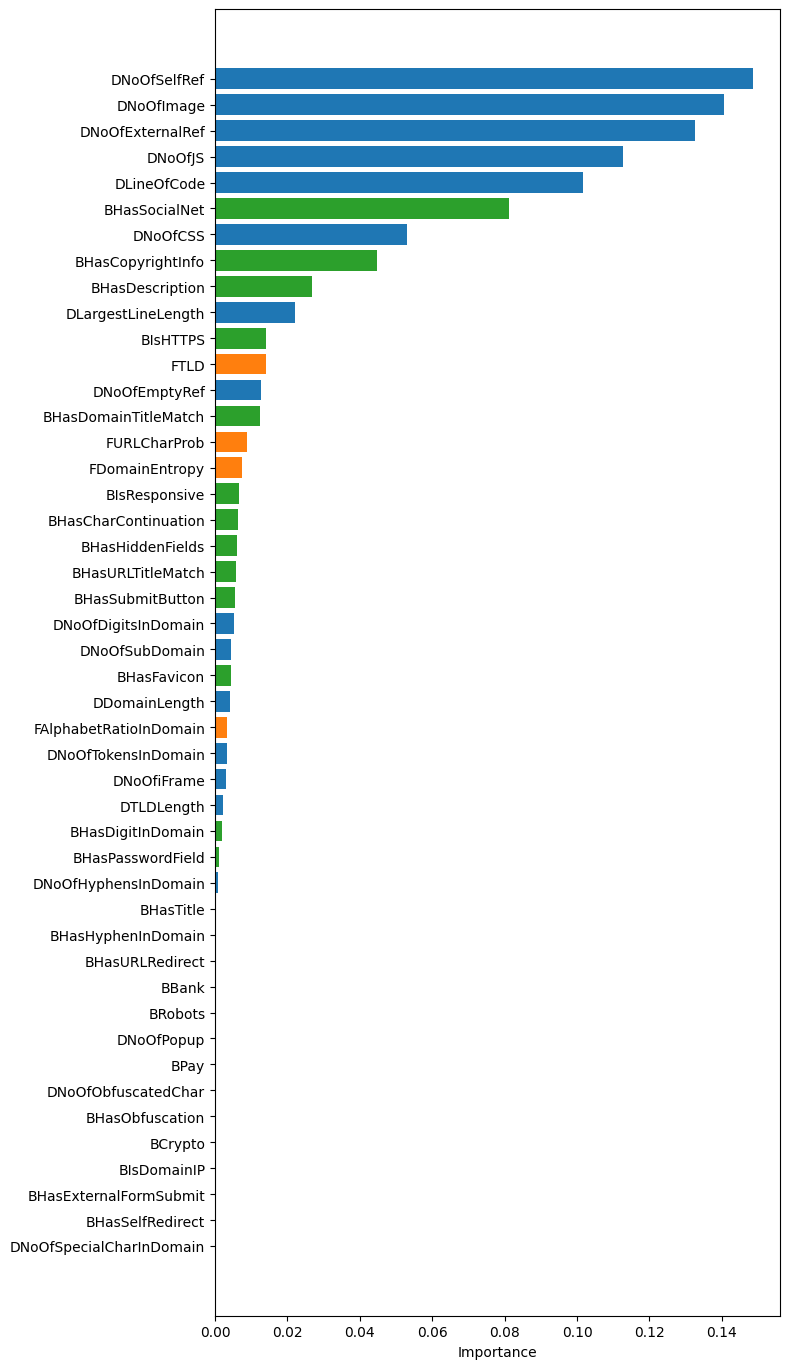

In [11]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


plt.figure(figsize=(8, 0.3 * len(importances)))
plt.barh(
    importances.index,
    importances.values,
    color=[feature_color(f) for f in importances.index]
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 1.5. L1-Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed

Cs = [1.0, 0.5, 0.1, 0.05, 0.01]


def fit_model(C):
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=500,
                    random_state=0,
                ),
            ),
        ]
    )
    pipe.fit(X_train, y_train)
    return pipe


models = Parallel(n_jobs=-1, backend="loky")(delayed(fit_model)(C) for C in Cs)
models = dict(zip(Cs, models))

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid t

In [13]:
for C, model in models.items():
    coefs = model.named_steps["clf"].coef_.ravel()
    print(f"{C}: {coefs}")

1.0: [-2.47355553e-01 -1.00474348e+01  9.99796238e-01  9.44450147e-01
 -1.07622184e+00  6.39023067e-01 -4.48432763e-01 -4.43726868e+00
  1.87622068e+00  1.56092584e+00 -8.30680112e+00  1.10321074e+00
  2.65111958e-01 -2.91952032e-02  1.07886747e-01 -2.58721199e-01
 -5.15137195e-02  8.06262461e-01  3.30571421e-01 -4.99126161e-02
 -4.45340731e-03  1.25234439e+00  2.98426625e-01  2.36341152e-01
 -4.33372597e-01 -9.03202371e-02  1.81479626e-01 -1.16731033e-02
  9.16921296e-01  1.99698511e+00  8.38406059e-01  2.08398262e+00
  2.35079266e+00 -5.50511035e-02  1.54692098e+00 -1.34469753e+00
 -1.75487453e-01 -3.96711914e-02 -6.75527438e-01  1.79508464e-01
  1.80814683e-02  5.27134208e-01  9.69380283e-02  1.02794109e+00
 -1.33846891e-01  3.22613102e-01]
0.5: [-2.40175060e-01 -9.05217018e+00  1.02408317e+00  9.22930529e-01
 -1.12461718e+00  6.36110804e-01 -6.18888691e-01 -2.76633617e+00
  1.89878342e+00  1.71635484e+00 -8.80981960e+00  1.24318874e+00
  2.72169207e-01 -7.35082105e-03  1.22556679e-

In [14]:
pd.Series(
    data=models[0.01].named_steps["clf"].coef_.ravel(),
    index=X_train.columns,
).abs().sort_values(ascending=True)

BIsDomainIP                 0.000000
DNoOfObfuscatedChar         0.000000
BRobots                     0.000000
BCrypto                     0.000000
BHasExternalFormSubmit      0.000000
DNoOfiFrame                 0.000000
DNoOfPopup                  0.000000
BHasSelfRedirect            0.000000
FDomainEntropy              0.000000
BHasHyphenInDomain          0.000000
DNoOfSpecialCharInDomain    0.000000
DNoOfEmptyRef               0.000000
BPay                        0.017225
BBank                       0.023425
BIsResponsive               0.038512
DNoOfTokensInDomain         0.074549
BHasObfuscation             0.079476
BHasDigitInDomain           0.105578
BHasURLRedirect             0.149949
DNoOfHyphensInDomain        0.159832
BHasURLTitleMatch           0.172076
FAlphabetRatioInDomain      0.177641
BHasSubmitButton            0.181688
BHasHiddenFields            0.200262
BHasFavicon                 0.220954
DDomainLength               0.259701
BHasPasswordField           0.268811
D

# 2. Scale and Check Variables

## 2.1. Scale variables

In [16]:
from sklearn.preprocessing import StandardScaler



# 3. Model Assumptions

## 3.1. Linearity of Logit

In [17]:
import statsmodels.api as sm

X_bt = X.copy()

for c in float_columns:
    X_bt[f"{c}_log"] = X[c] * np.log(X[c].clip(lower=1e-6))

X_bt = sm.add_constant(X_bt)
model = sm.Logit(y, X_bt).fit(disp=0)

bt_terms = [c for c in X_bt.columns if c.endswith("_log")]
model.pvalues[bt_terms]

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FTLD_log                      2.757020e-02
FURLCharProb_log              8.955150e-01
FAlphabetRatioInDomain_log    2.940226e-26
FDomainEntropy_log            7.765479e-31
dtype: float64

In [18]:
model.pvalues[bt_terms] < 0.05

FTLD_log                       True
FURLCharProb_log              False
FAlphabetRatioInDomain_log     True
FDomainEntropy_log             True
dtype: bool

All p-values are significant ($\alpha = 0.05$), except for `URLCharProb`.

## 3.2. No Perfect Multicollinearity

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_ = X.drop(columns=["FAlphabetRatioInDomain"])

X_vif = sm.add_constant(X_)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i)
     for i in range(1, X_vif.shape[1])],
    index=X_.columns
)

vif.sort_values(ascending=False)

DNoOfHyphensInDomain        4.575038
DDomainLength               4.148540
BHasDomainTitleMatch        4.055121
BHasURLTitleMatch           3.989533
DNoOfTokensInDomain         3.618591
BHasHyphenInDomain          3.270513
FDomainEntropy              3.259529
DNoOfDigitsInDomain         2.540208
BHasSocialNet               2.489014
BHasCharContinuation        2.475986
DNoOfSelfRef                2.274784
DNoOfSubDomain              2.217885
BHasCopyrightInfo           2.185364
DNoOfExternalRef            2.063276
BHasDigitInDomain           2.032016
BHasSubmitButton            1.980210
BHasDescription             1.940785
FURLCharProb                1.884766
BIsHTTPS                    1.818593
BIsResponsive               1.792113
BHasHiddenFields            1.740536
BHasTitle                   1.531169
BHasSelfRedirect            1.451483
FTLD                        1.450844
DTLDLength                  1.443024
BHasFavicon                 1.419757
BHasURLRedirect             1.418079
D

We have some problematic columns:
- `FAlphabetRatioInDomain`
- `DNoOfDigitsInDomain`
- `DDomainLength`

All of these features and some other features related to domain have high VIF.